In [14]:
import pyodbc
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go 

In [16]:
conn = pyodbc.connect( 
    'Driver={SQL Server};'
    'Server=DESKTOP-3TC82P7;'
    'Database=ProjectWeek;'
    'Trusted_Connection=yes;' 
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21096\3615440341.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


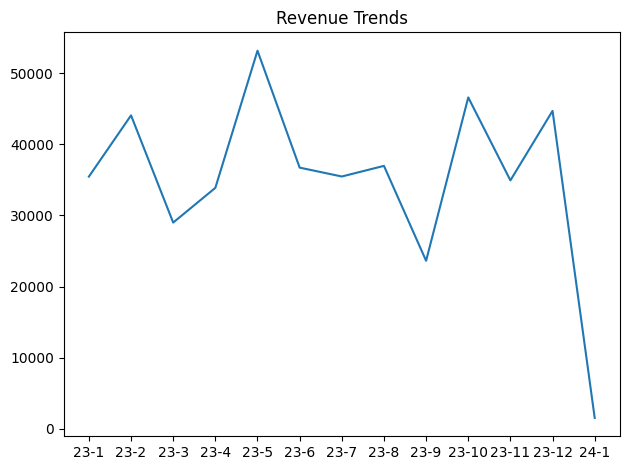

In [17]:
#Revenue By Year, Month
query = """
WITH CTE_aggregate as (
SELECT 
    SUBSTRING(CAST(YEAR(date) AS NVARCHAR), 3, 2)  AS year,
	MONTH(date) AS month,
	SUM(revenue) AS total_revenue
FROM dbo.retail_sales
GROUP BY YEAR(date), MONTH(date)
)
SELECT 
   CONCAT(year, '-', month) AS date,
   year,
   month,
   total_revenue
FROM CTE_aggregate
ORDER BY year, month;
"""

df = pd.read_sql(query, conn)
plt.plot(df['date'], df['total_revenue'])
plt.title('Revenue Trends')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21096\2066396532.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


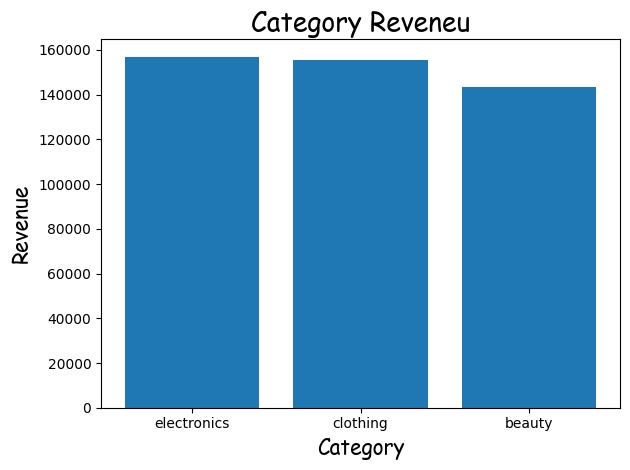

In [18]:
# Revenue By Product Category
query = """
SELECT 
    product_category,
	SUM(revenue) AS total_revenue
FROM dbo.retail_sales
GROUP BY product_category
ORDER BY SUM(revenue) DESC;
"""
df = pd.read_sql(query, conn)
plt.bar(df['product_category'], df['total_revenue'])
plt.xlabel('Category', family='Comic Sans Ms', fontsize=15)
plt.ylabel('Revenue', family='Comic Sans Ms', fontsize=15)
plt.title('Category Reveneu', family='Comic Sans Ms', fontsize=19)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21096\3558798940.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


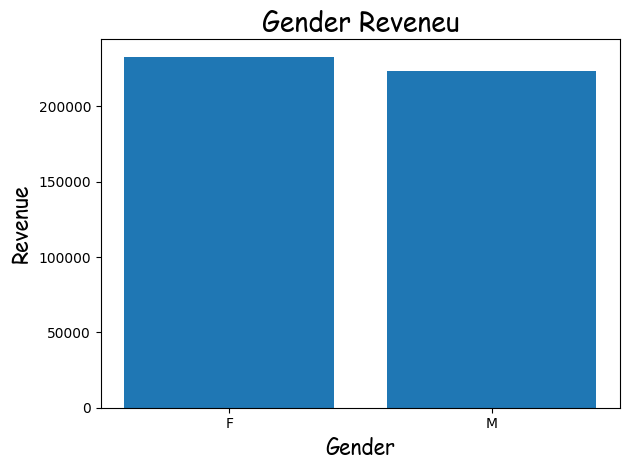

In [19]:
query = """
SELECT 
    gender,
	SUM(revenue)total_revenue
FROM dbo.retail_sales
GROUP BY gender
ORDER BY SUM(revenue) DESC;
"""
df = pd.read_sql(query, conn)
plt.bar(df['gender'], df['total_revenue'])
plt.xlabel('Gender', family='Comic Sans Ms', fontsize=15)
plt.ylabel('Revenue', family='Comic Sans Ms', fontsize=15)
plt.title('Gender Reveneu', family='Comic Sans Ms', fontsize=19)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21096\216201389.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


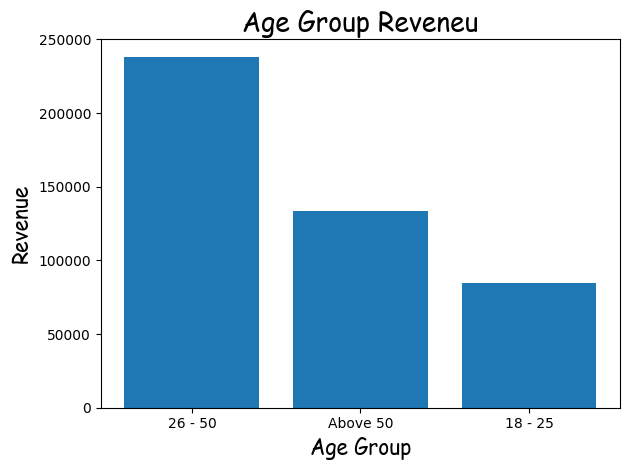

In [20]:
query = """
WITH CTE_Segment AS (
SELECT
	*,

	CASE WHEN age < 18 THEN 'Under 18'
		 WHEN age BETWEEN 18 AND 25 THEN '18 - 25'
		 WHEN age BETWEEN 26 AND 50 THEN '26 - 50'
		 ELSE 'Above 50'
	END AS age_group 
FROM dbo.retail_sales
)
SELECT 
	age_group,
	SUM(revenue)AS total_revenue
FROM CTE_Segment 
GROUP BY age_group;
"""
df = pd.read_sql(query, conn)
plt.bar(df['age_group'], df['total_revenue'])
plt.xlabel('Age Group', family='Comic Sans Ms', fontsize=15)
plt.ylabel('Revenue', family='Comic Sans Ms', fontsize=15)
plt.title('Age Group Reveneu', family='Comic Sans Ms', fontsize=19)
plt.tight_layout()
plt.show()